# Análisis de Docentes - Violencia Digital
Este notebook procesa exclusivamente los datos de docentes (educadores), integrando la limpieza de dimensiones demográficas y académicas, y calcula los índices de Conocimiento y Capacidades de Respuesta para exportar la capa final hacia Power BI.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de visualización
sns.set_theme(style="whitegrid")

# Crear carpeta output si no existe
os.makedirs('../output', exist_ok=True)

# Cargar datos crudos
df_docentes = pd.read_excel('../raw_data/BBDD_Docentes_dash.xlsx')
print(f"Datos cargados: {df_docentes.shape}")

Datos cargados: (187, 69)


## 1. Cálculo de Índices (Conocimiento y Capacidades de Respuesta)

In [2]:
def evaluar_conocimiento_docentes(df):
    # Preguntas conceptuales (Binarias)
    col_q1 = '1. ¿Cómo definiría usted la violencia digital? \nMarque la opción que mejor refleje su comprensión actual.'
    col_q4 = "4. ¿Qué es el 'Grooming' en el contexto digital?"
    col_q5 = "5. ¿Qué se entiende por 'Sextorsión'?"
    col_q6 = '6. ¿Cuál de los siguientes comportamientos corresponde a CSEA (explotación y abuso sexual de menores en línea)?'
    col_q8 = '8. ¿Qué es el ciberacoso o "cyberbullying"?'
    
    df['Puntaje_Q1'] = df[col_q1].apply(lambda x: 1 if 'agresión' in str(x).lower() else 0)
    df['Puntaje_Q4'] = df[col_q4].apply(lambda x: 1 if 'adulto contacta' in str(x).lower() else 0)
    df['Puntaje_Q5'] = df[col_q5].apply(lambda x: 1 if 'amenaza' in str(x).lower() or 'íntimas' in str(x).lower() else 0)
    df['Puntaje_Q6'] = df[col_q6].apply(lambda x: 1 if 'producción' in str(x).lower() or 'distribución' in str(x).lower() else 0)
    df['Puntaje_Q8'] = df[col_q8].apply(lambda x: 1 if 'hostigamiento' in str(x).lower() or 'burlas' in str(x).lower() else 0)
    
    # Preguntas escalares (1 a 4 o similar)
    cols_q2 = [c for c in df.columns if c.startswith('2. ')]
    for c in cols_q2:
        df[c + '_num'] = df[c].astype(str).str.extract(r'(\d+)')[0].astype(float).fillna(0)
    df['Puntaje_Q2'] = df[[c + '_num' for c in cols_q2]].sum(axis=1)
    
    def mapear_q3(x):
        t = str(x).lower()
        if 'muy capaz' in t: return 3
        if 'medianamente' in t: return 2
        if 'poco' in t: return 1
        return 0
    col_q3 = '3. ¿En qué medida se siente capaz de reconocer una situación de violencia digital que afecte a un/a estudiante y de brindarle orientación inicial?'
    df['Puntaje_Q3'] = df[col_q3].apply(mapear_q3)
    
    def mapear_frecuencia(x):
        t = str(x).lower()
        if 'siempre' in t: return 4
        if 'frecuentemente' in t: return 3
        if 'a veces' in t: return 2
        if 'raramente' in t: return 1
        return 0
    
    col_q12 = '12. ¿Con qué frecuencia aborda temas de seguridad digital o uso responsable de internet en sus clases?'
    col_q13 = '13. ¿Con qué frecuencia incorpora actividades o contenidos sobre prevención de violencia digital en su planificación curricular?'
    df['Puntaje_Q12'] = df[col_q12].apply(mapear_frecuencia)
    df['Puntaje_Q13'] = df[col_q13].apply(mapear_frecuencia)
    
    def mapear_q14(x):
        t = str(x).lower()
        if 'completa' in t: return 3
        if 'una o dos' in t: return 2
        if 'solo he' in t or 'investigación' in t: return 1
        return 0
    col_q14 = '14. ¿Ha recibido alguna formación o capacitación sobre violencia digital o seguridad en línea en los últimos dos años?'
    df['Puntaje_Q14'] = df[col_q14].apply(mapear_q14)
    
    def mapear_q15(x):
        t = str(x).lower()
        if 'muy preparado' in t: return 3
        if 'medianamente' in t: return 2
        if 'poco' in t: return 1
        return 0
    col_q15 = '15. ¿En qué medida se siente preparado/a para enseñar a sus estudiantes cómo protegerse en internet?'
    df['Puntaje_Q15'] = df[col_q15].apply(mapear_q15)
    
    # Índice de Conocimiento Total
    cols_conocimiento = ['Puntaje_Q1', 'Puntaje_Q4', 'Puntaje_Q5', 'Puntaje_Q6', 'Puntaje_Q8',
                         'Puntaje_Q2', 'Puntaje_Q3', 'Puntaje_Q12', 'Puntaje_Q13', 'Puntaje_Q14', 'Puntaje_Q15']
    df['Indice_Conocimiento'] = df[cols_conocimiento].sum(axis=1)
    
    return df

def evaluar_capacidades_docentes(df):
    cols_q16 = [c for c in df.columns if c.startswith('16. ')]
    def mapear_q16(x):
        t = str(x).lower()
        if 'con seguridad' in t: return 3
        if 'algo de ayuda' in t: return 2
        if 'con dificultad' in t: return 1
        return 0
    
    for c in cols_q16:
        df[c + '_num'] = df[c].apply(mapear_q16)
    df['Puntaje_Q16'] = df[[c + '_num' for c in cols_q16]].sum(axis=1)
    
    col_q21 = '21. ¿Ha tenido experiencia con prácticas restaurativas (círculos de diálogo, mediación entre pares, acuerdos de reparación) en el abordaje de conflictos escolares?'
    def mapear_q21(x):
        t = str(x).lower()
        if 'regularmente' in t: return 3
        if 'alguna vez' in t: return 2
        if 'concepto' in t: return 1
        return 0
    df['Puntaje_Q21'] = df[col_q21].apply(mapear_q21)
    
    col_q22 = '22. ¿Con qué frecuencia utiliza algún mecanismo de mediación o diálogo para resolver conflictos entre estudiantes en lugar de recurrir a sanciones disciplinarias?'
    def mapear_q22(x):
        t = str(x).lower()
        if 'siempre' in t: return 3
        if 'a veces' in t: return 2
        if 'raramente' in t: return 1
        return 0
    df['Puntaje_Q22'] = df[col_q22].apply(mapear_q22)
    
    df['Indice_Capacidades_Respuesta'] = df['Puntaje_Q16'] + df['Puntaje_Q21'] + df['Puntaje_Q22']
    return df

df_docentes = evaluar_conocimiento_docentes(df_docentes)
df_docentes = evaluar_capacidades_docentes(df_docentes)

# Normalización a escala 0-100
df_docentes['Indice_Conocimiento_Norm'] = (df_docentes['Indice_Conocimiento'] / df_docentes['Indice_Conocimiento'].max()) * 100
df_docentes['Indice_Capacidades_Respuesta_Norm'] = (df_docentes['Indice_Capacidades_Respuesta'] / df_docentes['Indice_Capacidades_Respuesta'].max()) * 100

print("Índices de docentes calculados y normalizados a 100 correctamente.")

Índices de docentes calculados y normalizados a 100 correctamente.


## 2. Limpieza de Dimensiones Geográficas y Demográficas

In [3]:
# 1. Unidad Educativa y Municipio
df_docentes['Dim_Unidad_Educativa'] = df_docentes['Unidad educativa'].astype(str).str.strip().str.title()
df_docentes['Dim_Unidad_Educativa'] = df_docentes['Dim_Unidad_Educativa'].replace('Nan', 'No Reportado')

df_docentes['Dim_Municipio'] = df_docentes['Municipio'].astype(str).str.strip().str.title()
df_docentes['Dim_Municipio'] = df_docentes['Dim_Municipio'].replace('Nan', 'No Reportado')

# 2. Nivel, Experiencia, Materia, Género, Indígena, Idioma
dimensiones = {
    'D1. ¿En qué nivel o niveles enseña actualmente?': 'Dim_Nivel',
    'D2. ¿Cuántos años de experiencia docente tiene en total?': 'Dim_Experiencia',
    'D3. ¿Cuál es su materia y/o asignatura principal?': 'Dim_Materia',
    'D4. ¿Cuál es su género?': 'Dim_Genero',
    'D5 ¿Se identifica como parte de alguna nación o pueblo indígena originario campesino?': 'Dim_Indigena',
    'D6. ¿Cuál es su idioma materno?': 'Dim_Idioma'
}

for col_orig, col_nueva in dimensiones.items():
    if col_orig in df_docentes.columns:
        df_docentes[col_nueva] = df_docentes[col_orig].astype(str).str.strip().str.title()
        df_docentes[col_nueva] = df_docentes[col_nueva].replace('Nan', 'No Reportado')

print("Dimensiones de docentes limpiadas y creadas.")

Dimensiones de docentes limpiadas y creadas.


## 3. Visualizaciones Intermedias

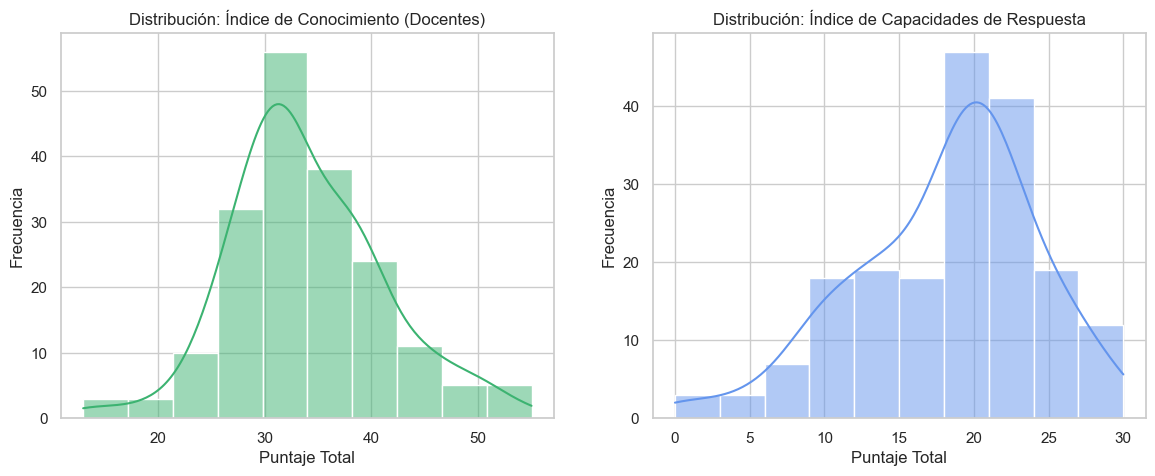

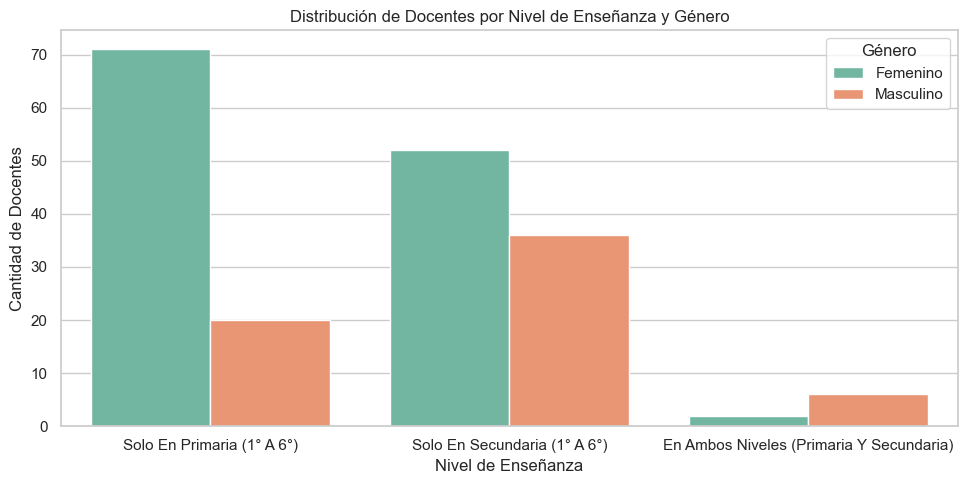

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma: Indice de Conocimiento
sns.histplot(df_docentes['Indice_Conocimiento'], bins=10, kde=True, ax=axes[0], color='mediumseagreen')
axes[0].set_title('Distribución: Índice de Conocimiento (Docentes)')
axes[0].set_xlabel('Puntaje Total')
axes[0].set_ylabel('Frecuencia')

# Histograma: Indice de Capacidades
sns.histplot(df_docentes['Indice_Capacidades_Respuesta'], bins=10, kde=True, ax=axes[1], color='cornflowerblue')
axes[1].set_title('Distribución: Índice de Capacidades de Respuesta')
axes[1].set_xlabel('Puntaje Total')
axes[1].set_ylabel('Frecuencia')


# Gráfico: Distribución por Género y Nivel
plt.figure(figsize=(10, 5))
sns.countplot(data=df_docentes, x='Dim_Nivel', hue='Dim_Genero', palette='Set2')
plt.title('Distribución de Docentes por Nivel de Enseñanza y Género')
plt.xlabel('Nivel de Enseñanza')
plt.ylabel('Cantidad de Docentes')
plt.legend(title='Género')
plt.tight_layout()
plt.show()

## 4. Exportación de Resultados

In [5]:
# Seleccionamos las columnas clave para el Dashboard
columnas_finales = [
    'ID_Control',
    'Dim_Municipio',
    'Dim_Unidad_Educativa',
    'Dim_Nivel',
    'Dim_Experiencia',
    'Dim_Materia',
    'Dim_Genero',
    'Dim_Indigena',
    'Dim_Idioma',
    'Indice_Conocimiento',
    'Indice_Conocimiento_Norm',
    'Indice_Capacidades_Respuesta',
    'Indice_Capacidades_Respuesta_Norm'
]

cols_export = [c for c in columnas_finales if c in df_docentes.columns]
df_final = df_docentes[cols_export].copy()

output_path = '../output/df_docentes_final.xlsx'
df_final.to_excel(output_path, index=False)
print(f"Archivo final de docentes exportado exitosamente a: {output_path}")

Archivo final de docentes exportado exitosamente a: ../output/df_docentes_final.xlsx
